In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, default_data_collator
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix

# Load your new, fully trained model
model_path = "../.saved_models/UpdatedTwitterRoBERTaV2" 

# Load using the Auto classes so the vocabulary maps perfectly
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path, 
    problem_type="multi_label_classification"
)

# Initialize a basic Trainer just for generating predictions
trainer = Trainer(
    model=model,
    data_collator=default_data_collator
)

/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2323.99it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


In [2]:
# Load GoEmotions Dataset
goEmotionsDataset = load_dataset('go_emotions')
sentimentLabels = goEmotionsDataset['train'].features['labels'].feature.names
num_labels = len(sentimentLabels)

def tokenize_and_encode(batch):
    tokenized = tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
    
    # Ensure this is a list of float32 arrays
    batch_labels = []   
    for labels_list in batch["labels"]:
        encoded = np.zeros(num_labels, dtype=np.float32)
        encoded[labels_list] = 1.0
        batch_labels.append(encoded)
        
    tokenized["labels"] = batch_labels
    return tokenized

print("Tokenizing Validation and Test sets...")
# We use the validation set to calculate thresholds
val_dataset = goEmotionsDataset['validation'].map(tokenize_and_encode, batched=True, remove_columns=["text", "id"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# We use the test set for the final evaluation
test_dataset = goEmotionsDataset['test'].map(tokenize_and_encode, batched=True, remove_columns=["text", "id"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print("Done!")

Tokenizing Validation and Test sets...
Done!


In [6]:
def optimize_thresholds(trainer, eval_dataset):
    print("Generating predictions to calculate F0.5 thresholds...")

    # Remove labels temporarily to avoid loss computation
    eval_dataset_no_labels = eval_dataset.remove_columns("labels")

    predictions = trainer.predict(eval_dataset_no_labels)

    logits = predictions.predictions
    if isinstance(logits, tuple):
        logits = logits[0]

    true_labels = np.array(eval_dataset["labels"])

    probs = 1 / (1 + np.exp(-logits))

    best_thresholds = []

    for i in range(num_labels):
        best_t = 0.5
        best_fscore = 0.0

        for t in np.arange(0.1, 0.95, 0.05):
            preds = (probs[:, i] >= t).astype(int)
            score = fbeta_score(true_labels[:, i], preds, beta=0.5, zero_division=0)

            if score > best_fscore:
                best_fscore = score
                best_t = t

        best_thresholds.append(best_t)

    return np.array(best_thresholds)

optimal_thresholds = optimize_thresholds(trainer, val_dataset)

print("\n--- Optimal Thresholds Per Class (F0.5) ---")
for name, thresh in zip(sentimentLabels, optimal_thresholds):
    print(f"{name.capitalize():<15}: {thresh:.2f}")

Generating predictions to calculate F0.5 thresholds...



--- Optimal Thresholds Per Class (F0.5) ---
Admiration     : 0.65
Amusement      : 0.65
Anger          : 0.55
Annoyance      : 0.50
Approval       : 0.50
Caring         : 0.60
Confusion      : 0.65
Curiosity      : 0.55
Desire         : 0.50
Disappointment : 0.55
Disapproval    : 0.60
Disgust        : 0.70
Embarrassment  : 0.70
Excitement     : 0.55
Fear           : 0.50
Gratitude      : 0.70
Grief          : 0.70
Joy            : 0.60
Love           : 0.75
Nervousness    : 0.65
Optimism       : 0.60
Pride          : 0.50
Realization    : 0.65
Relief         : 0.20
Remorse        : 0.55
Sadness        : 0.70
Surprise       : 0.65
Neutral        : 0.50


Starting latency test...


Total inference time: 31.1272 seconds
Average latency: 5.74 ms per post
Throughput: 174.35 posts/sec

--- 28-Class Classification Report ---
                precision    recall  f1-score   support

    admiration       0.77      0.56      0.65       504
     amusement       0.82      0.75      0.78       264
         anger       0.54      0.38      0.45       198
     annoyance       0.41      0.28      0.33       320
      approval       0.54      0.33      0.41       351
        caring       0.60      0.33      0.43       135
     confusion       0.63      0.14      0.23       153
     curiosity       0.58      0.32      0.41       284
        desire       0.62      0.42      0.50        83
disappointment       0.44      0.18      0.25       151
   disapproval       0.49      0.29      0.36       267
       disgust       0.77      0.24      0.37       123
 embarrassment       0.67      0.27      0.38        37
    excitement       0.60      0.36      0.45       103
          fear    

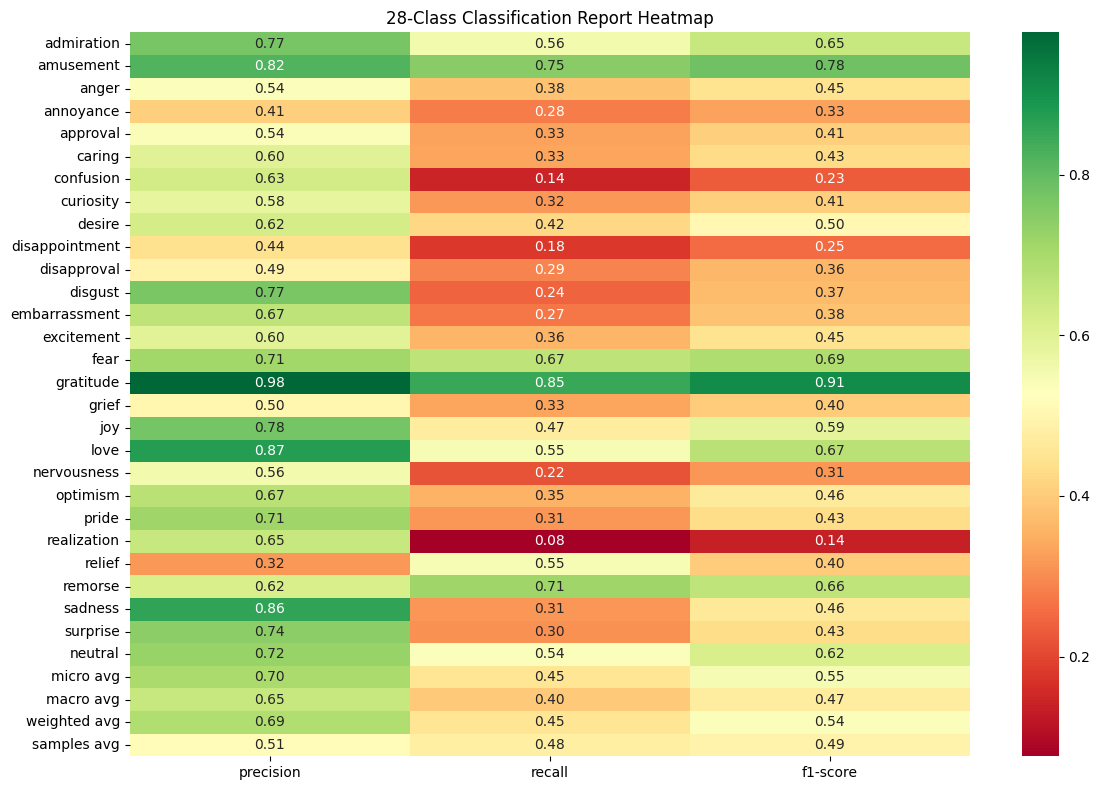


--- 3-Bucket Classification Report ---
              precision    recall  f1-score   support

    Positive       0.83      0.82      0.83      2104
    Negative       0.67      0.72      0.69      1184
     Neutral       0.74      0.72      0.73      2139

    accuracy                           0.76      5427
   macro avg       0.75      0.75      0.75      5427
weighted avg       0.76      0.76      0.76      5427



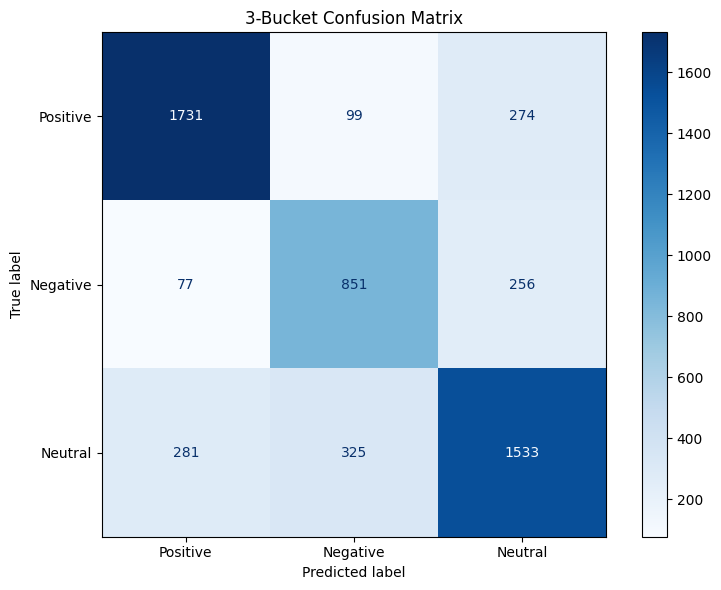

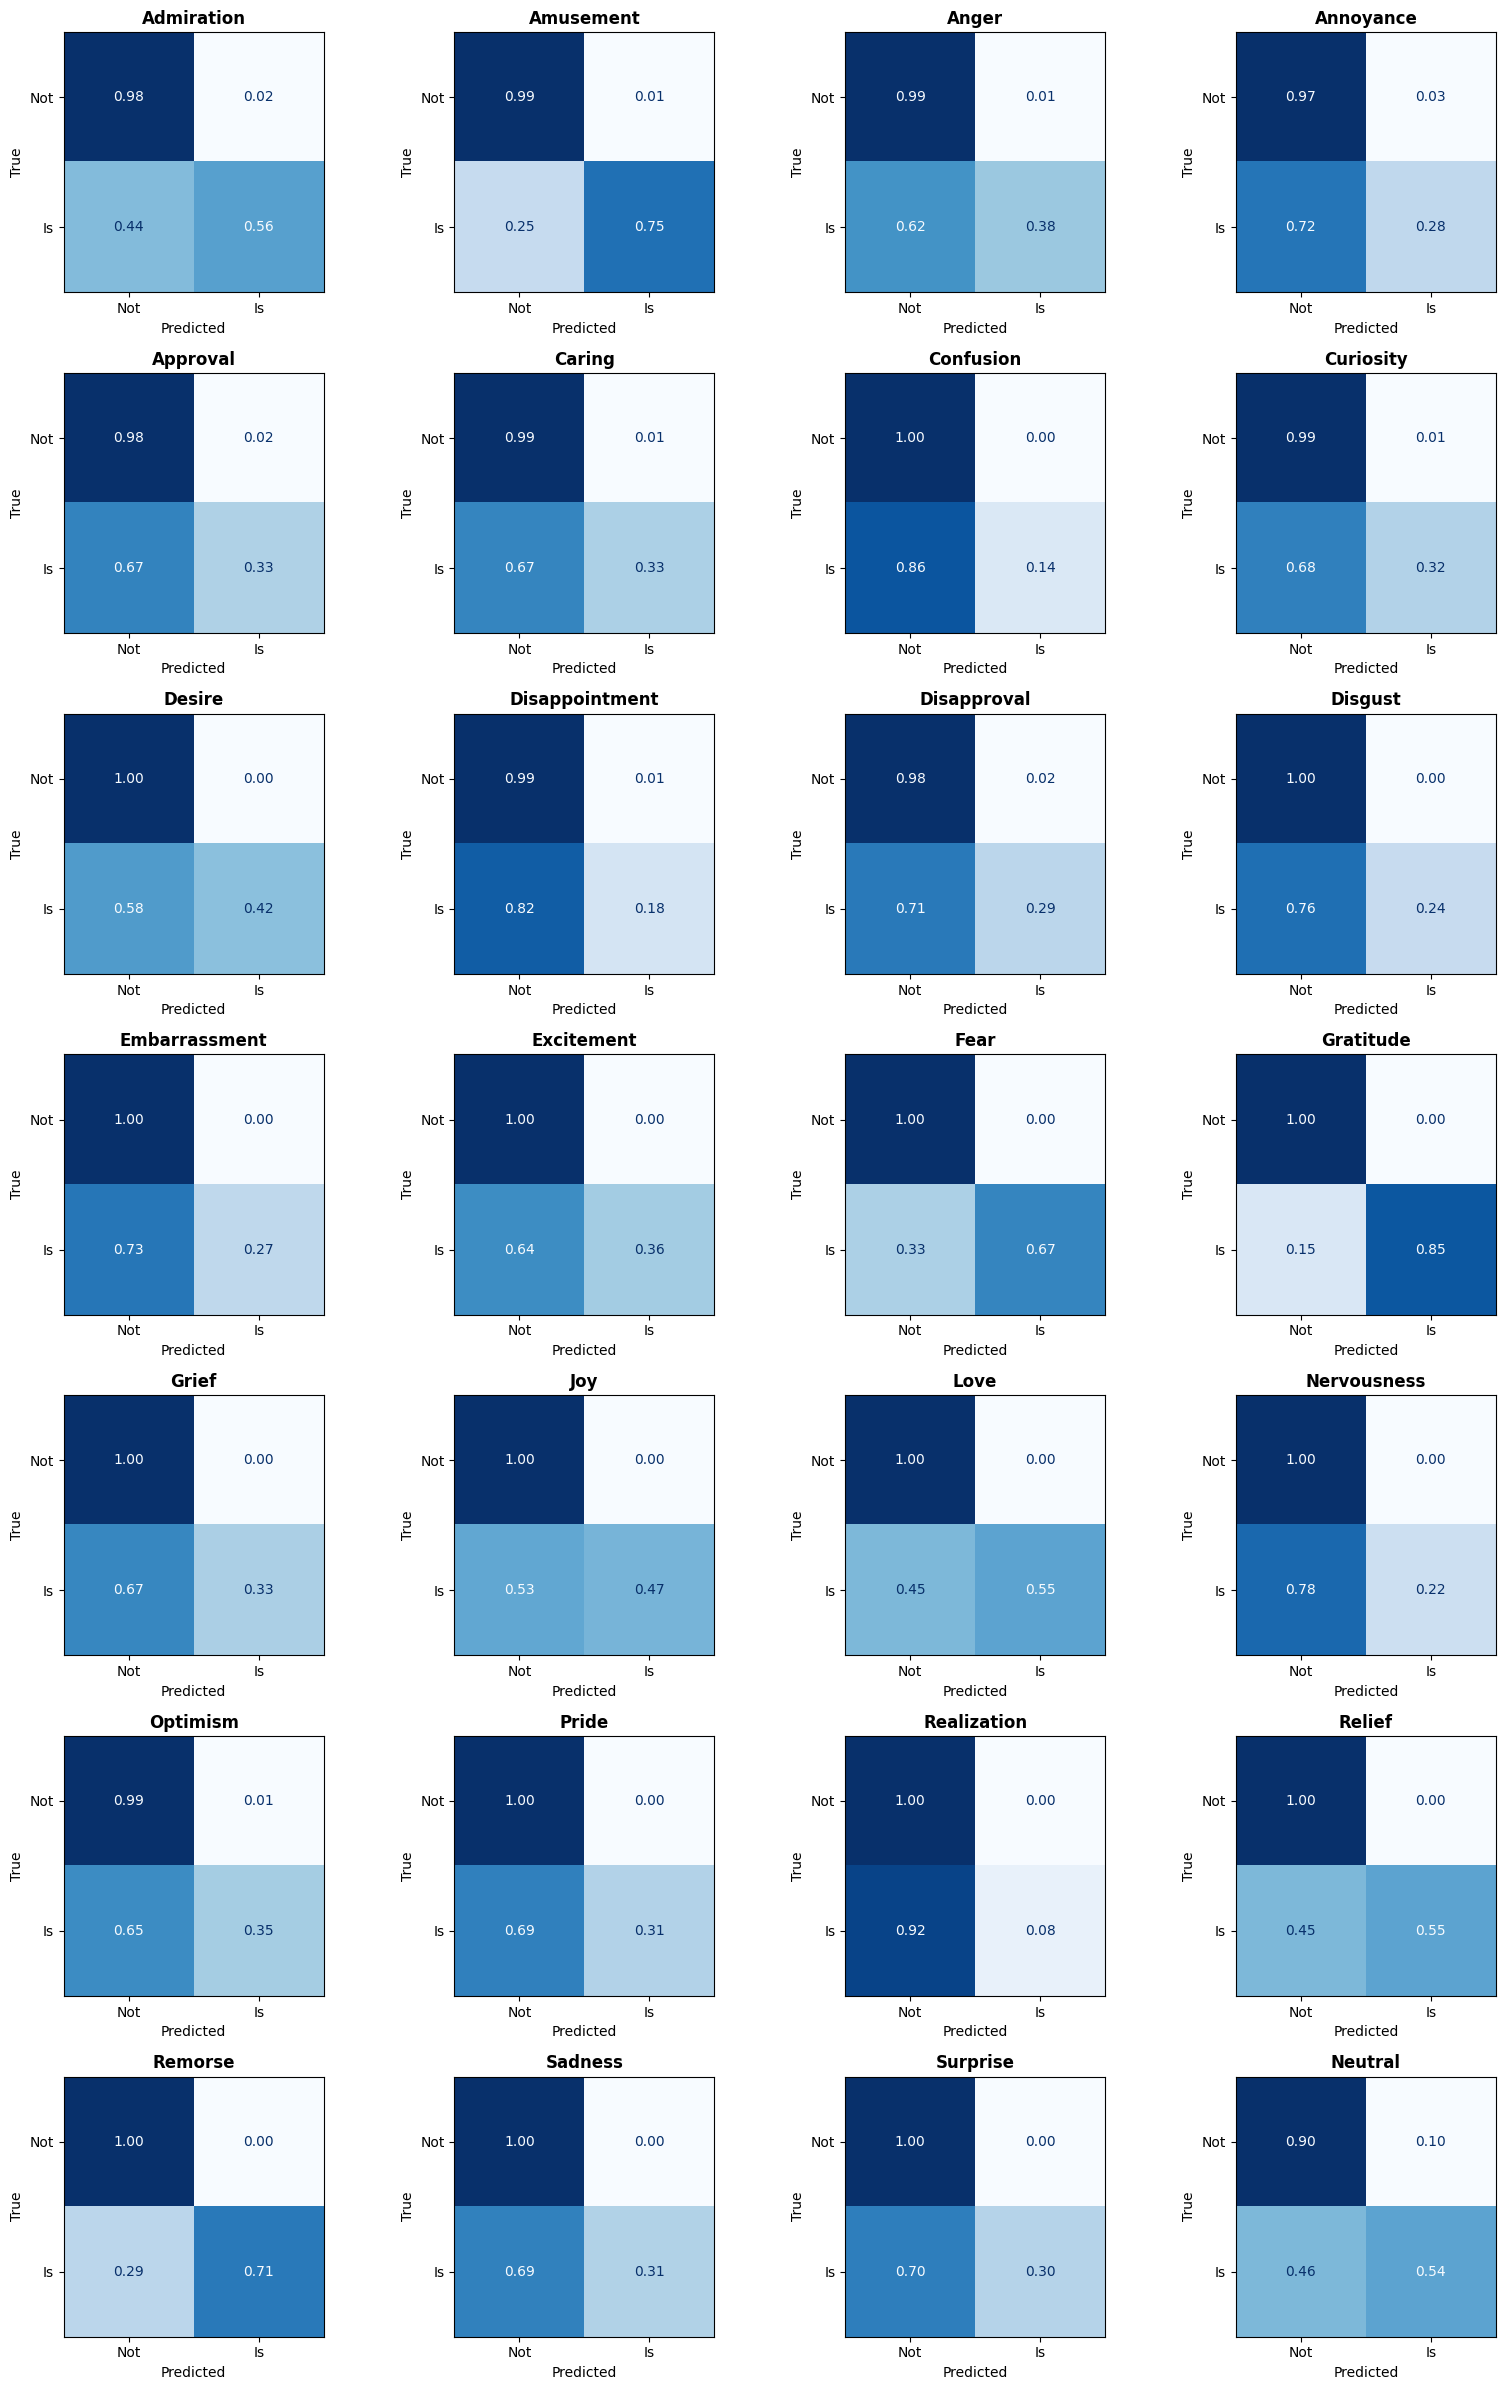

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix

print("Starting latency test...")

# -------------------------------------------------
# 1️⃣ SAVE TRUE LABELS BEFORE REMOVING THEM
# -------------------------------------------------
true_labels = np.array(test_dataset["labels"])
num_samples = len(test_dataset)

# Remove labels so Trainer does NOT compute BCE loss
test_dataset_no_labels = test_dataset.remove_columns("labels")

# -------------------------------------------------
# 2️⃣ LATENCY TEST
# -------------------------------------------------
start_time = time.time()
predictions = trainer.predict(test_dataset_no_labels)
end_time = time.time()

total_time = end_time - start_time

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average latency: {(total_time / num_samples) * 1000:.2f} ms per post")
print(f"Throughput: {num_samples / total_time:.2f} posts/sec")

# -------------------------------------------------
# 3️⃣ EXTRACT LOGITS + APPLY SIGMOID
# -------------------------------------------------
logits = predictions.predictions
if isinstance(logits, tuple):
    logits = logits[0]

sigmoid_outputs = 1 / (1 + np.exp(-logits))

# Apply per-class optimal thresholds
predicted_labels = (sigmoid_outputs > optimal_thresholds).astype(int)

# -------------------------------------------------
# 4️⃣ 28-CLASS CLASSIFICATION REPORT
# -------------------------------------------------
print("\n--- 28-Class Classification Report ---")

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=sentimentLabels,
    zero_division=0
))

report_dict = classification_report(
    true_labels,
    predicted_labels,
    target_names=sentimentLabels,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

plt.figure(figsize=(12, 8))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("28-Class Classification Report Heatmap")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5️⃣ 3-BUCKET MAPPING
# -------------------------------------------------
sentimentMap = {
    "positive": ["admiration", "amusement", "approval", "caring", "desire",
                 "excitement", "gratitude", "joy", "love", "optimism",
                 "pride", "relief"],
    "negative": ["anger", "annoyance", "disappointment", "disapproval",
                 "disgust", "embarrassment", "fear", "grief",
                 "nervousness", "remorse", "sadness"],
    "neutral": ["neutral", "realization", "surprise",
                "curiosity", "confusion"]
}

pos_indices = [sentimentLabels.index(e) for e in sentimentMap["positive"] if e in sentimentLabels]
neg_indices = [sentimentLabels.index(e) for e in sentimentMap["negative"] if e in sentimentLabels]
neu_indices = [sentimentLabels.index(e) for e in sentimentMap["neutral"] if e in sentimentLabels]

def get_bucket_preds(matrix):
    bucket_preds = []
    for row in matrix:
        pos_score = np.max(row[pos_indices]) if len(pos_indices) else 0
        neg_score = np.max(row[neg_indices]) if len(neg_indices) else 0
        neu_score = np.max(row[neu_indices]) if len(neu_indices) else 0
        bucket_preds.append(np.argmax([pos_score, neg_score, neu_score]))
    return bucket_preds

y_true_buckets = get_bucket_preds(true_labels)
y_pred_buckets = get_bucket_preds(sigmoid_outputs)

print("\n--- 3-Bucket Classification Report ---")

print(classification_report(
    y_true_buckets,
    y_pred_buckets,
    target_names=["Positive", "Negative", "Neutral"],
    zero_division=0
))

# -------------------------------------------------
# 6️⃣ 3-BUCKET CONFUSION MATRIX
# -------------------------------------------------
cm = confusion_matrix(y_true_buckets, y_pred_buckets)

cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Positive", "Negative", "Neutral"]
)

fig, ax = plt.subplots(figsize=(8, 6))
cmd.plot(cmap="Blues", ax=ax)
plt.title("3-Bucket Confusion Matrix")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 7️⃣ MULTI-LABEL CONFUSION MATRICES (28 EMOTIONS)
# -------------------------------------------------
mcm = multilabel_confusion_matrix(true_labels, predicted_labels)

fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.ravel()

for i, (emotion_name, matrix) in enumerate(zip(sentimentLabels, mcm)):

    row_sums = matrix.sum(axis=1)
    matrix_normalized = np.divide(
        matrix.astype(float),
        row_sums[:, np.newaxis],
        out=np.zeros_like(matrix, dtype=float),
        where=row_sums[:, np.newaxis] != 0
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix_normalized,
        display_labels=["Not", "Is"]
    )

    disp.plot(ax=axes[i], cmap="Blues", colorbar=False, values_format=".2f")

    axes[i].set_title(f"{emotion_name.capitalize()}", fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()